# Final Project: Gesture Recognition and Computer Inputs

Here is the link to the [github repository](https://github.com/nwetmore99/PIC16B-Project/tree/main). Here you can find all the files for this project as well as download them to try it out for yourself! Once you download the repository, all you have to do is navigate to the correct folder in terminal and type `python gui.py` to run the program.

Full URL to Repository: https://github.com/nwetmore99/PIC16B-Project/tree/main

## Overview

> In this project, our aim was to create a program that could perform simple tasks such as controlling volume and media with nothing but a wave of the hand. Using Google's MediaPipe as well as a neural network, we took location nodes of a user's hand tracked by the camera on their device and matched it with set gestures that were linked to various media control functions. The ideal intended use is for example, having Spotify and our program run in the background while working on an essay. This way, the user could just put their   hand up to their computer to change volume, pause, skip, etc. However, this program also works for any media the computer is playing: Youtube, Netflix, and more.





> Below is a flowchart describing generally how our project works, and below that we dive deeper into the four main components of our project: MediaPipe, PyTorch, media scripts, and PySimpleGUI.

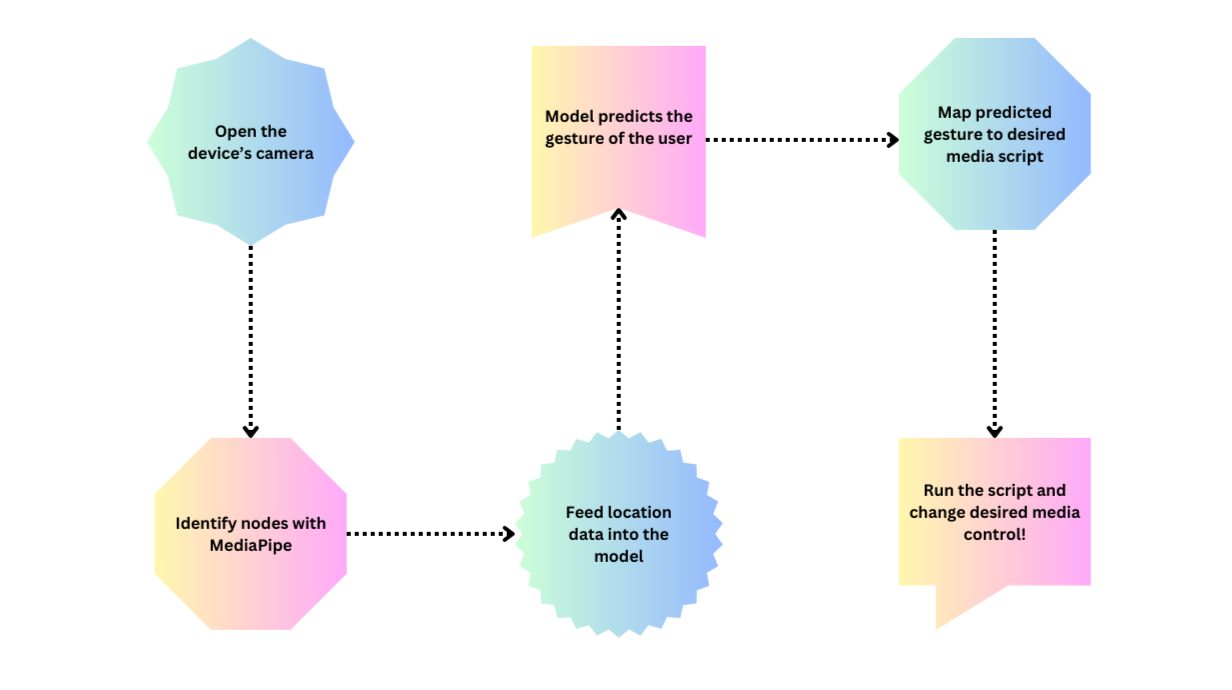

## Technical Component 1: MediaPipe

Image 1
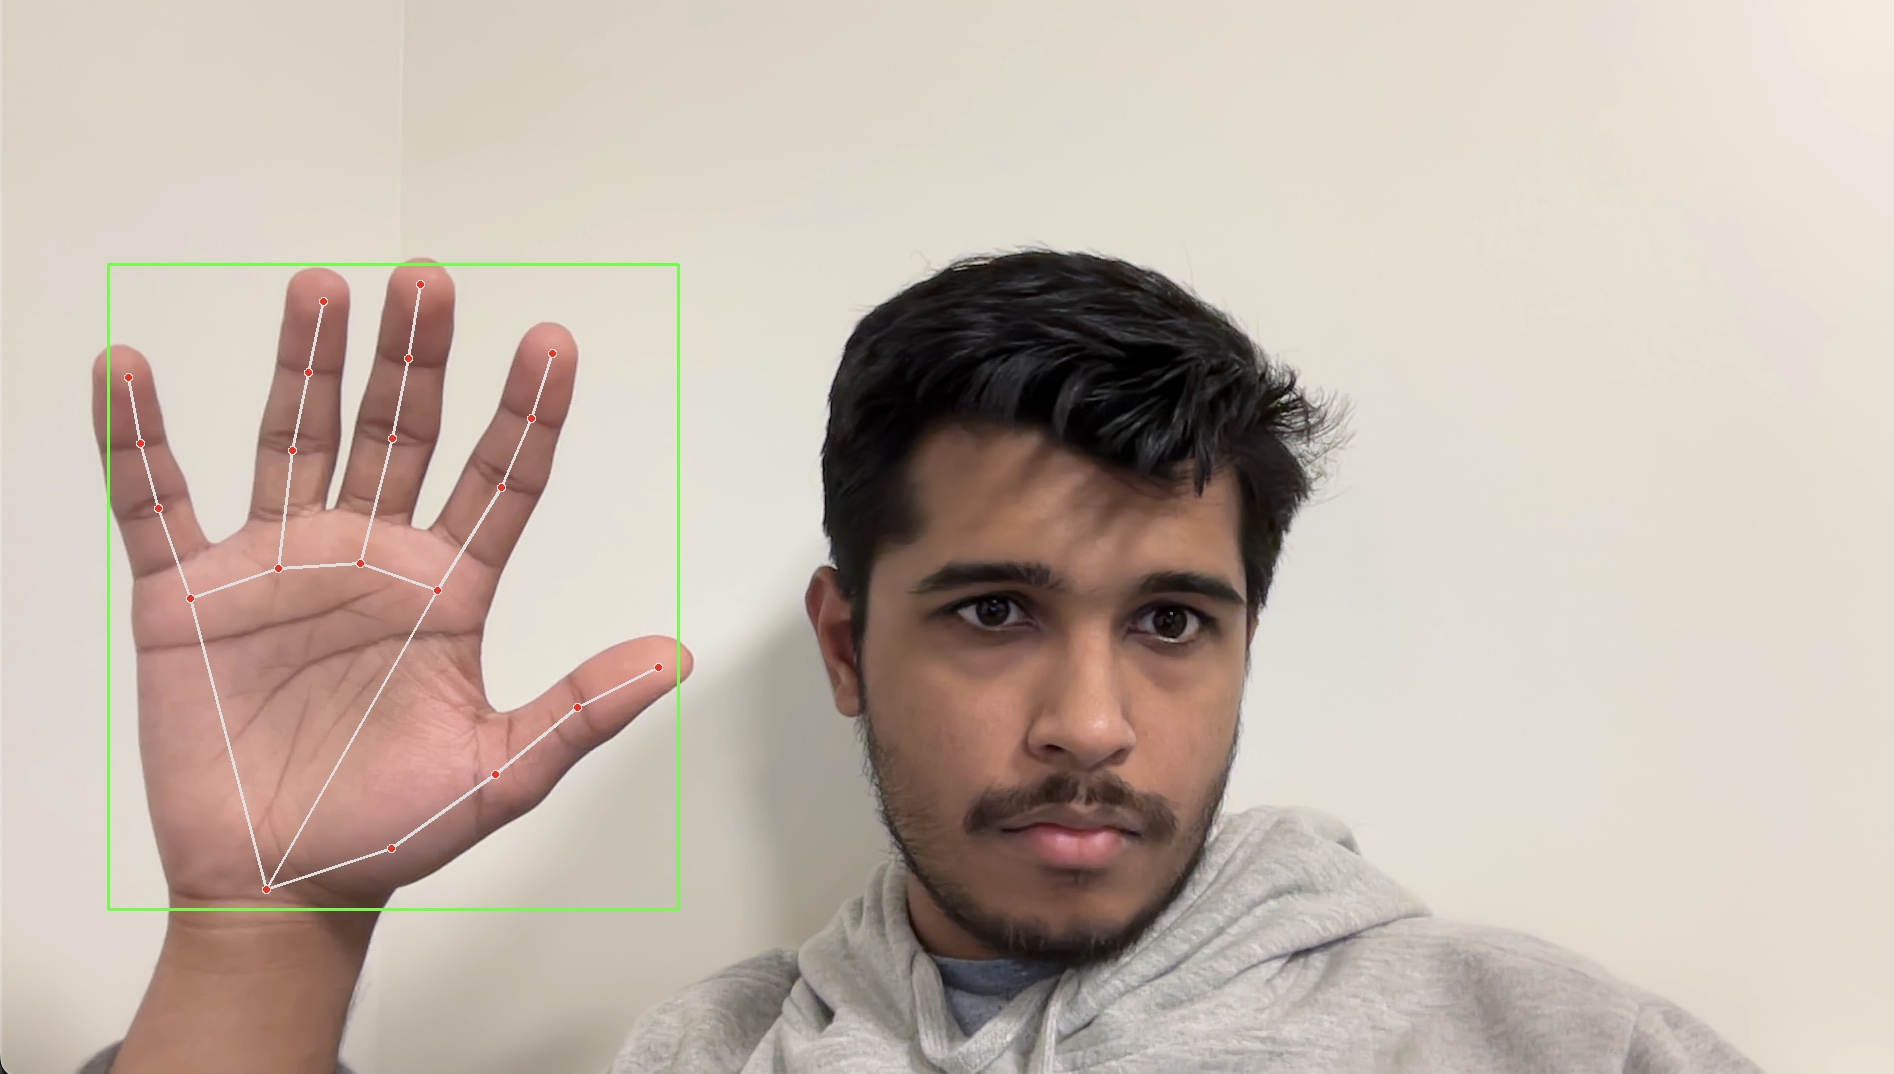

Image 2
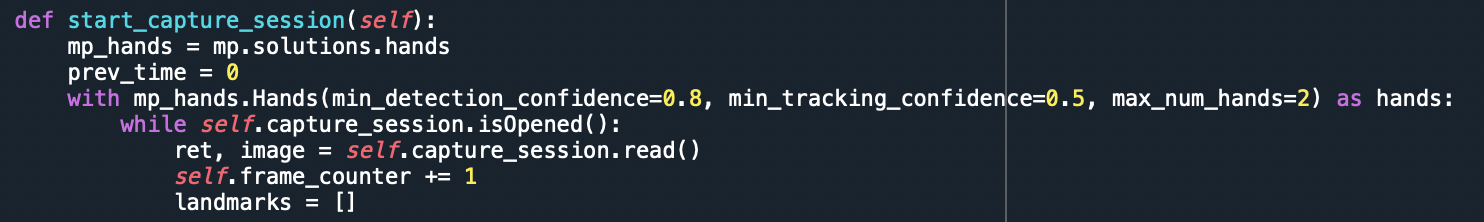

MediaPipe is a package by Google which takes in pictures and translates them into coordinates. We will use this package to teach the model how to detect a hand gesture. The idea is that specific gestures will have roughly similar hand shapes and the model will train off that.

First, MediaPipe is applied to the training data, which is a collection of hand pictures. These are translated through MediaPipe as coordinates and passed to the model with the name of the associated gesture. In the actual program, MediaPipe is connected to OpenCV to translate a hand into coordinates and is synced with a predictive model. This is demonstrated in the main image, with the code in the following image.

## Technical Component 2: PyTorch

Image 1
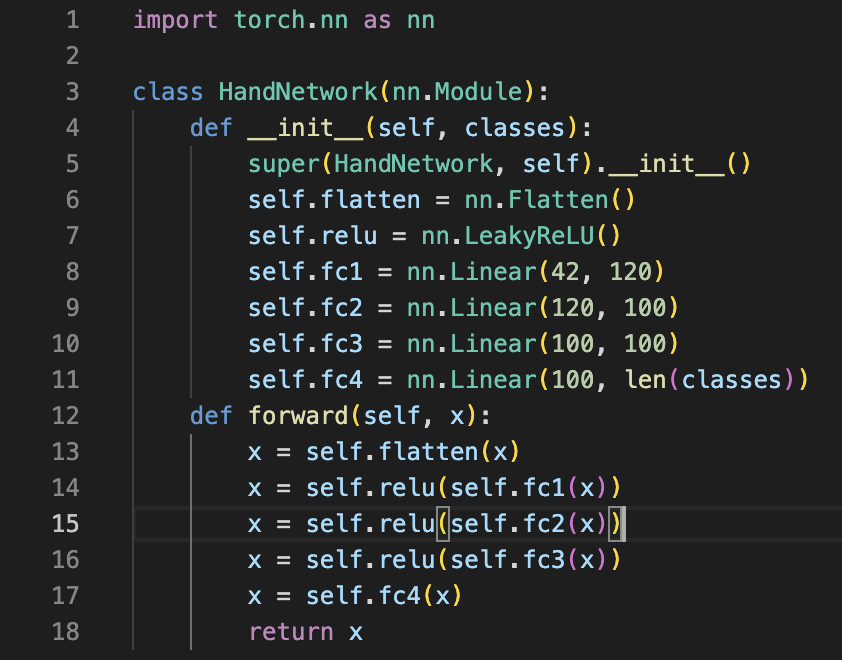

Image 2
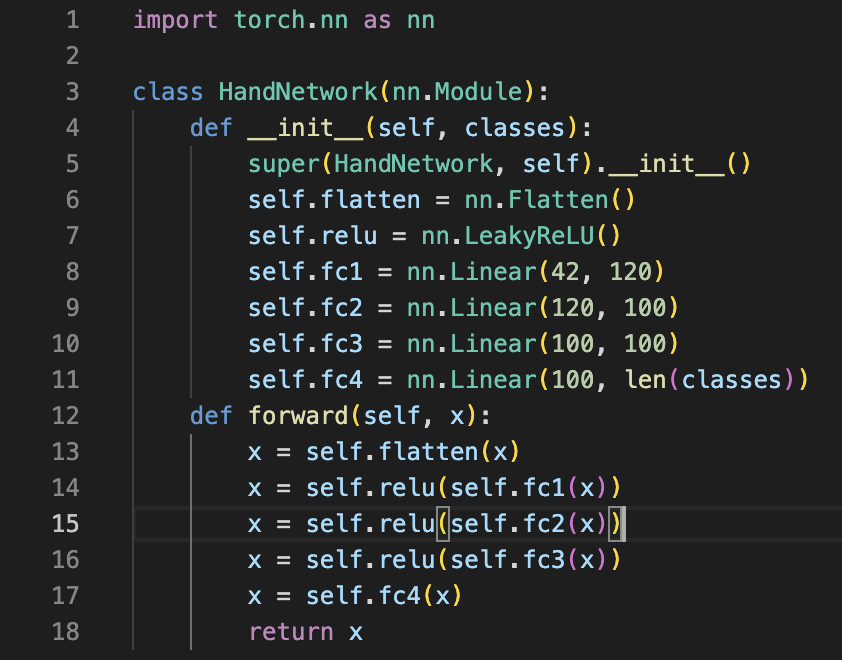

Us getting the coordinates of the hands was a great first step, but we still need to figure out how to train the model! We had to first create some loops to check the name of the file (which would indicate the class it is) and add it to the training data. We also used one-hot-encoded vectors to ensure that the model wouldn't be confused and think there was some inherent order to the labels. We tried a couple of generic classifiers, like k Nearest Neighbors and Suppport Vector Machines, and our accuracy was actually pretty good, around 90-93%. However, we decided to implement another class, called Background, and this introduced a lot of issues for us. To preface this, we needed to add a background class because the program would sometimes predict a gesture at a high confidence score even though they weren't actively performing anything. This meant that actions like scratching your nose, resting your face on your hand, etc. could trigger actions like changing the volume or skipping a track! We wanted this to be as practical as possible, which is why we tried to add a background class. When we did this, however, our generic classifier accuracies plummeted, down to around 60-70%! This is most likely because the pictures we used for the background class were extremely varied, since there are a lot of gestureless/idle actions one might do that we wouldn't want classified as a gesture. We had to switch tracks, and we decided to go with a neural network.

To create the neural network, we simply used a flatten layer since each coordinate had an x and y part. We then used 4 linear layers to put the whole network together. Of course, when we went through a fully connected linear layer, we used an activation function after each pass, except for the last linear layer. We started off with ReLU, but then switched to LeakyReLU since we found that it had slightly better results. We used Cross Entropy as the loss function, and SGD as the optimizer. We had the learning rate be around 0.005-0.01, and we also had momentum of 0.1, allowing us to avoid being stuck at local minimums. We trained this model for about 300 epochs, and our best validation loss ended up being around 0.22. When we tested our accuracy on our validation set, we got a 95% accuracy score. Again, this was with our background class, so this was miles better than the other classifiers that we used, and we stuck with the neural network.

## Technical Component 3: Controlling Media

Image 1
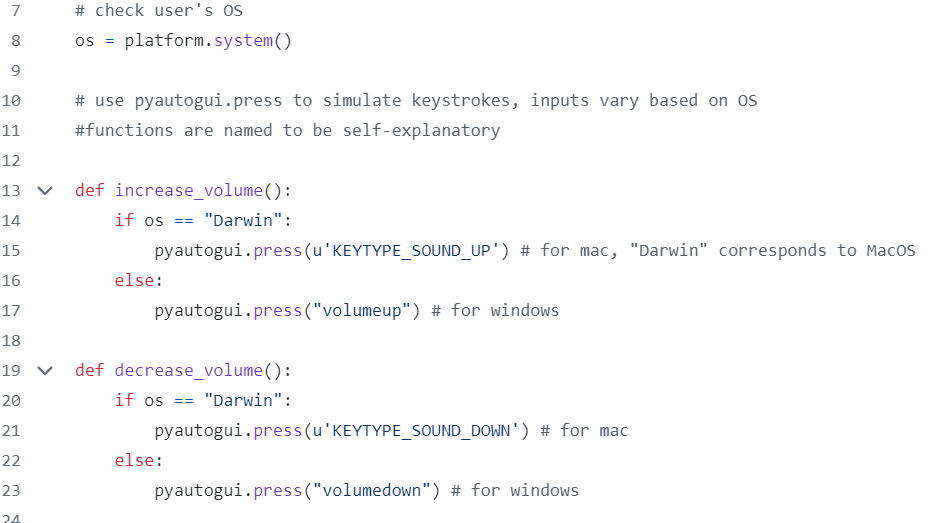

Image 2
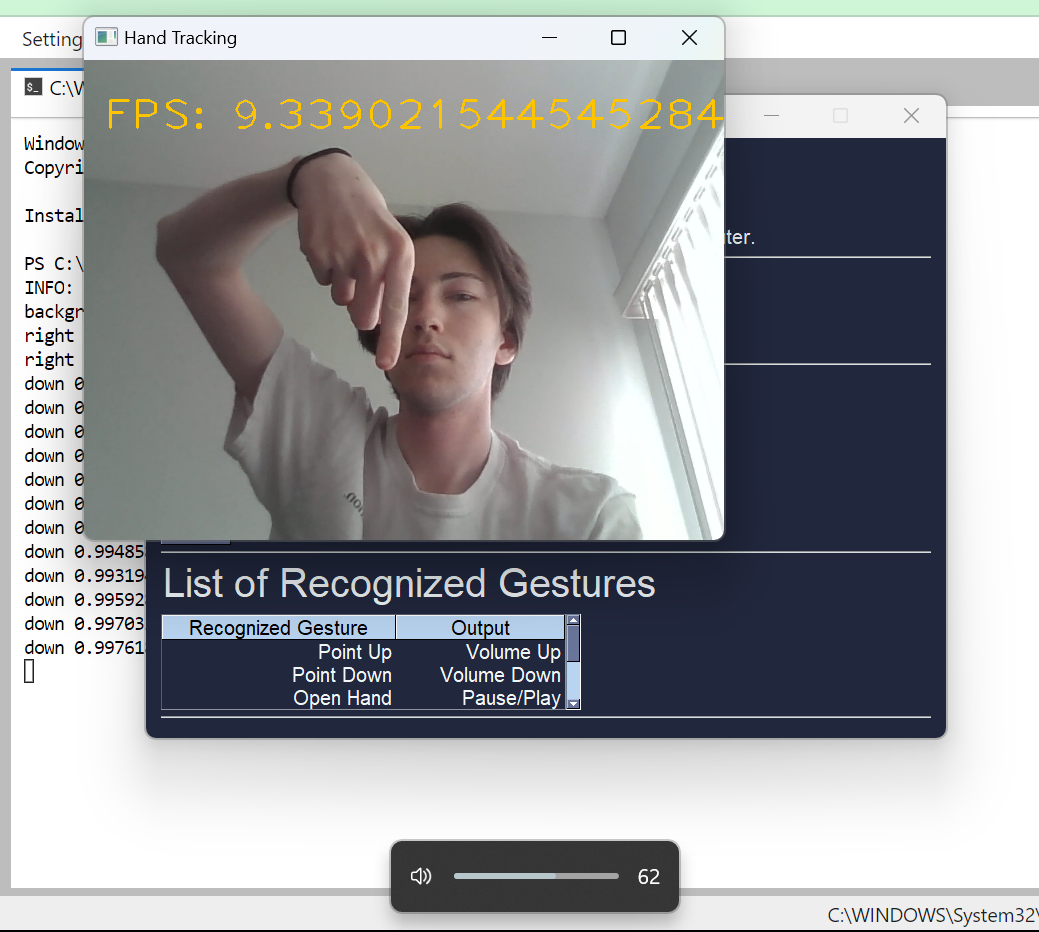

In the above code snippet, we used the `platform` package and the `.system()` method to read in the user's operating system. This outputs `'Darwin'` from MacOS and `'Windows'` for Windows, so we used if statements to make sure the proper key commands were being used. We also have a couple of our media functions visibile in the snippet. Using `pyautogui.press` we can simulate keystroke activity and thus control things like the volume remotely. These functions are stored in our `gestures.py` file which is imported for the `camera.py` file to utilize as can be seen in the PyTorch section.

In the second image, the 'down' gesture is being used to lower the volume. The volume slider is active at the bottom of the screen, showing it is being changed.

## Technical Component 4: GUI with `PySimpleGui`

Image 1
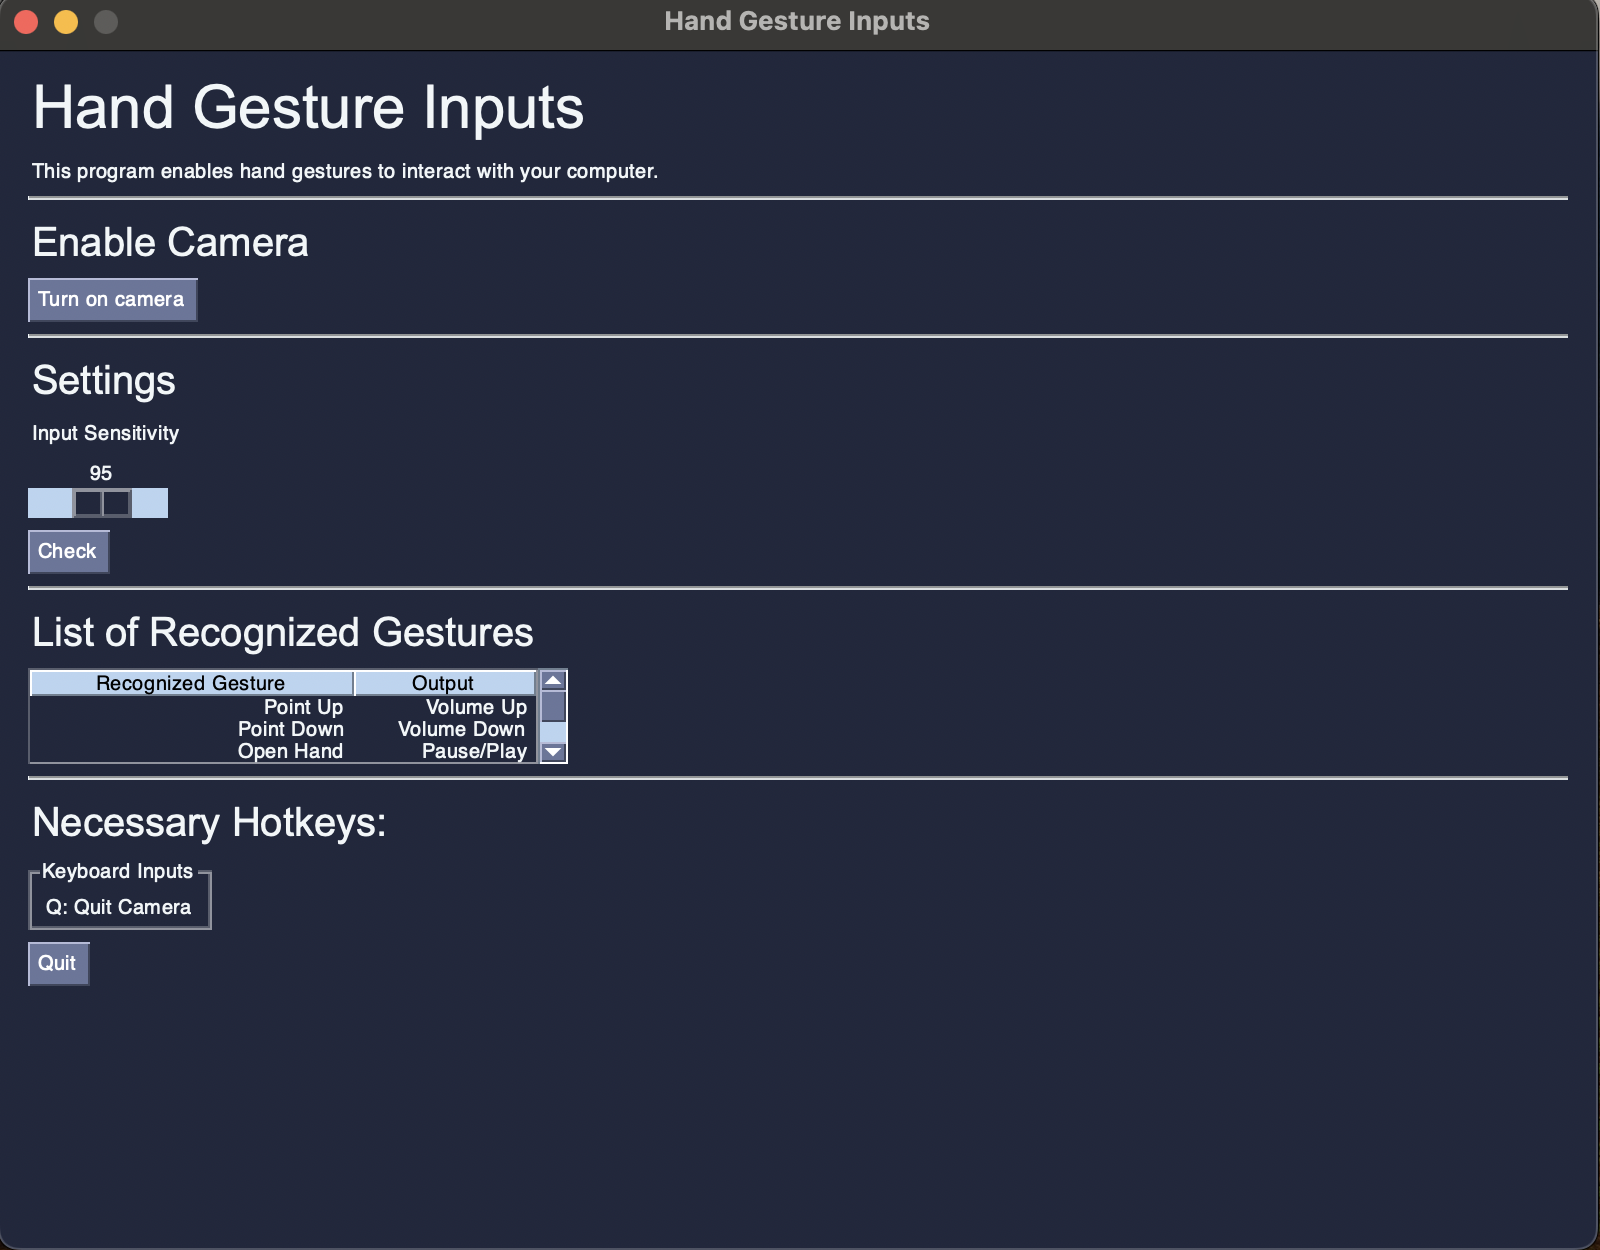

Image 2 
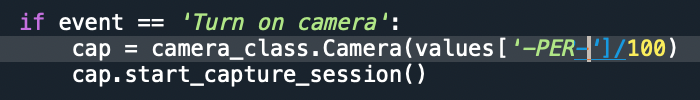

The GUI is designed to create a more user-friendly medium to interact with the program. The goal is to communicate more information to the user regarding the use of the program and include modifyable parameters for the user to adjust the sensitivity of the model.

Information on enabling the camera is initialized as the first possible input. More information regarding the list of recognized gestures is included in a table. The last tab lists hotkeys for the program. The only hotkey implemented was to turn off the camera, or Q.

The GUI was linked to the `Camera` class, with an instance of the class being initialized and ran upon clicking the "Turn on camera" button. From there, OpenCV is initialized to enable your camera. This is demonstrated in the second figure.

Lastly, the GUI includes an adjustable parameter for the user to modify. This allows for the modification of the model's input sensitivity, or how confident the model must be in order to read the input. The slider input is passed through the class and divided by 100 to convert into a usable input for the `Camera` object. This is demonstrated in the third image of this section. There is also a "Check" button, where the console outputs the value of the given slider input. This is a troubleshooting feature.

## Concluding Remarks

To wrap up, we believe this to be a successful endeavor of creating gesture
recognition software! Ideas for future direction may include adding a feature where users can record their own gesture and add it to the model, or a more extensive list of macros that the gestures can perform for the user to pick from. Ethical ramifications of our project are pretty limited, MediaPipe picks up all skin tones very well, and this program should be accessible for anyone. Some concerns however could be security, in that the program has access to the user's camera. We would have to learn more about encryption/data protection for this. Additionally if we allow users to create their own gestures, that calls into possiblitiy inappropriate or hateful gestures. We would need to implement some sort of database of hateful gestures in order to counteraact and block these.

These issues would mainly arise with a much larger user base and thus we did not put much thought into these potential hazards. Overall we are very proud of our work and think this project is a very cool application of the skills we have developed in PIC 16B.
